In [3]:
import cv2
import numpy as np
import os
import random
from pathlib import Path

# 1. SETUP PATHS
# Adjust these if your folder names are slightly different
LOGO_DIR = r"C:\Users\Dani_\OneDrive - University of Westminster\Desktop\SparkUpTaskDanis\Week 4\logos"
BG_DIR = r"C:\Users\Dani_\OneDrive - University of Westminster\Desktop\SparkUpTaskDanis\Week 4\backgrounds"
TRAIN_IMG = Path("dataset/train/images")
TRAIN_LBL = Path("dataset/train/labels")
VAL_IMG = Path("dataset/val/images")
VAL_LBL = Path("dataset/val/labels")

# Create directories if they don't exist
for p in [TRAIN_IMG, TRAIN_LBL, VAL_IMG, VAL_LBL]:
    p.mkdir(parents=True, exist_ok=True)

def generate_data(num_images, img_out, lbl_out):
    logo_files = sorted([f for f in os.listdir(LOGO_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))])
    bg_files = [f for f in os.listdir(BG_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))]

    for i in range(num_images):
        # Pick random background and logo
        bg_path = os.path.join(BG_DIR, random.choice(bg_files))
        class_id = random.randint(0, len(logo_files) - 1)
        logo_path = os.path.join(LOGO_DIR, logo_files[class_id])

        # Load images (using IMREAD_UNCHANGED to keep transparency if PNG)
        bg = cv2.imread(bg_path)
        logo = cv2.imread(logo_path, cv2.IMREAD_UNCHANGED)
        
        if bg is None or logo is None: continue

        # Resize background to YOLO standard
        bg = cv2.resize(bg, (640, 640))
        bg_h, bg_w = bg.shape[:2]

        # Randomly scale logo (between 10% and 30% of background width)
        scale = random.uniform(0.1, 0.3)
        new_w = int(bg_w * scale)
        new_h = int(logo.shape[0] * (new_w / logo.shape[1]))
        logo_resized = cv2.resize(logo, (new_w, new_h))

        # Randomly place logo
        x_offset = random.randint(0, bg_w - new_w)
        y_offset = random.randint(0, bg_h - new_h)

        # Overlay logo (handles transparency)
        if logo_resized.shape[2] == 4: # PNG with Alpha
            alpha_logo = logo_resized[:, :, 3] / 255.0
            alpha_bg = 1.0 - alpha_logo
            for c in range(0, 3):
                bg[y_offset:y_offset+new_h, x_offset:x_offset+new_w, c] = (
                    alpha_logo * logo_resized[:, :, c] +
                    alpha_bg * bg[y_offset:y_offset+new_h, x_offset:x_offset+new_w, c]
                )
        else: # Simple overlay if no alpha
            bg[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = logo_resized[:, :, :3]

        # CALCULATE YOLO NORMALIZED COORDINATES
        x_center = (x_offset + new_w / 2) / bg_w
        y_center = (y_offset + new_h / 2) / bg_h
        norm_w = new_w / bg_w
        norm_h = new_h / bg_h

        # SAVE FILES
        file_name = f"gen_{i}_{class_id}.jpg"
        cv2.imwrite(str(img_out / file_name), bg)
        with open(lbl_out / file_name.replace(".jpg", ".txt"), "w") as f:
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}")

# Generate 300 images for training and 60 for validation
print("Generating training data...")
generate_data(300, TRAIN_IMG, TRAIN_LBL)
print("Generating validation data...")
generate_data(60, VAL_IMG, VAL_LBL)
print("✅ Done! Check your dataset folder.")

Generating training data...
Generating validation data...
✅ Done! Check your dataset folder.


In [5]:
import os
import torch
from ultralytics import YOLO

# 1. Force synchronous reporting to prevent the crash-loop
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

# 2. Clear the GPU memory 'garbage' from the last crash
torch.cuda.empty_cache()

# 3. Load model
model = YOLO('yolo11n.pt')

# 4. Train using the NEW path (outside of OneDrive)
results = model.train(
    data=r"D:\Personal (Academic)\SparkUpTaskDanis\Week 4\LogoProject\data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,          # You can use 8 or 16 safely now
    workers=0,        # Keep at 0 for Windows stability
    amp=False,        
    device=0,         # Use your RTX 4050
    name='logo_final'
)

Ultralytics 8.3.240  Python-3.13.7 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Personal (Academic)\SparkUpTaskDanis\Week 4\LogoProject\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=logo_final5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

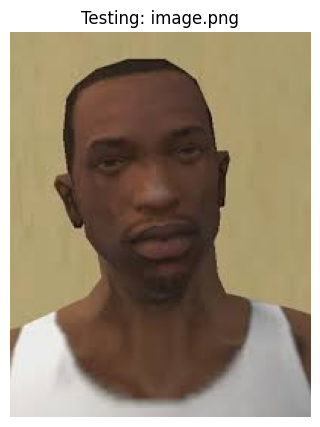

--- Stats for: image.png ---
Result: ❌ Unknown
------------------------------


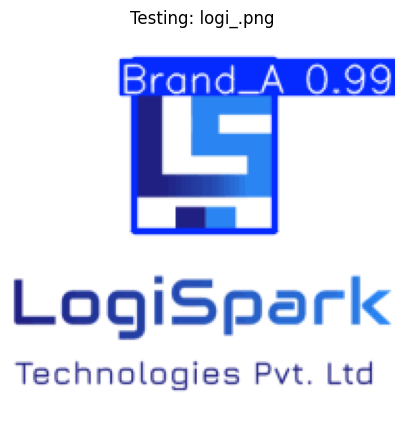

--- Stats for: logi_.png ---
Result: ✅ Detected Logispark (99.05%)
------------------------------


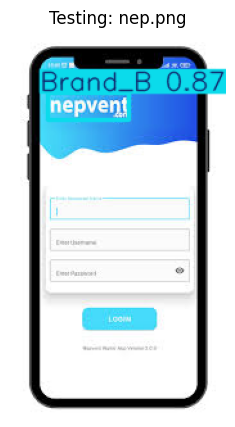

--- Stats for: nep.png ---
Result: ✅ Detected nepvet (87.37%)
------------------------------


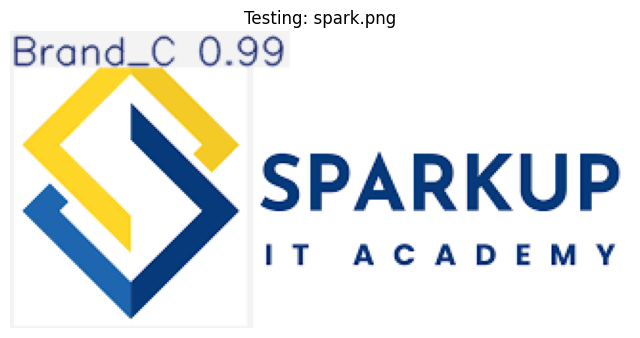

--- Stats for: spark.png ---
Result: ✅ Detected sparkUp (98.71%)
------------------------------


In [52]:
import os
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. Load the model from your C: drive
model = YOLO(r"D:\Personal (Academic)\SparkUpTaskDanis\Week 4\runs\detect\logo_final5\weights\best.pt")

# 2. Define your placeholder names
my_real_names = {
    0: "Logispark",
    1: "nepvet",
    2: "sparkUp"
}

# 3. SET THE FOLDER PATH
logo_folder = r"D:\Personal (Academic)\SparkUpTaskDanis\Week 4\test"

if not os.path.exists(logo_folder):
    print(f"❌ Error: The folder '{logo_folder}' was not found.")
else:
    images = [f for f in os.listdir(logo_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    for img_name in images:
        full_path = os.path.join(logo_folder, img_name)
        
        # Run inference using your GPU
        # We use a slightly lower conf (0.4) to see more results
        results = model.predict(source=full_path, conf=0.4, device=0, verbose=False)
        
        # --- NEW: DISPLAY IMAGE ABOVE STATS ---
        # Plot the boxes onto the image
        res_plotted = results[0].plot() 
        # Convert BGR (OpenCV format) to RGB (Matplotlib format)
        res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(8, 5))
        plt.imshow(res_rgb)
        plt.title(f"Testing: {img_name}")
        plt.axis('off')
        plt.show()
        # --------------------------------------

        print(f"--- Stats for: {img_name} ---")
        if len(results[0].boxes) == 0:
            print("Result: ❌ Unknown")
        else:
            for box in results[0].boxes:
                class_id = int(box.cls[0])
                clean_name = my_real_names.get(class_id, "Unknown")
                print(f"Result: ✅ Detected {clean_name} ({float(box.conf[0]):.2%})")
        print("-" * 30)